**Loading Tools**

In [1]:
!pip install tensorflow 
!pip install keras 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 6.0 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 5.29.5 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.3 which is incompatible.
pydrive2 1.21.3 r

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential,load_model
from keras.layers import Dense,Conv2D,BatchNormalization,MaxPooling2D,Flatten,Dropout
from keras.callbacks import EarlyStopping,ModelCheckpoint,ReduceLROnPlateau
from keras.utils import plot_model
from keras.applications.densenet import DenseNet201
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.model_selection import train_test_split

2025-12-11 19:52:48.909184: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765482769.110089      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765482769.161606      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


**DataFrame**

In [3]:
def dataframe(path):
    image_path,class_name = [],[]
    for folder in os.listdir(path):
        new_path = os.path.join(path,folder)
        for img in tqdm(os.listdir(new_path),desc="Creation DataFrame", leave=False):
            image_path.append(os.path.join(new_path,img))
            class_name.append(folder)
    return pd.DataFrame({"Image Path":image_path,"Target":class_name})

In [4]:
train_df = dataframe("/kaggle/input/melanoma-cancer-dataset/train")
test_df = dataframe("/kaggle/input/melanoma-cancer-dataset/test")
train_df.head()

,Image Path,Target
0,/kaggle/input/melanoma-cancer-dataset/train/Be...,Benign
1,/kaggle/input/melanoma-cancer-dataset/train/Be...,Benign
2,/kaggle/input/melanoma-cancer-dataset/train/Be...,Benign
3,/kaggle/input/melanoma-cancer-dataset/train/Be...,Benign
4,/kaggle/input/melanoma-cancer-dataset/train/Be...,Benign


**EDA**

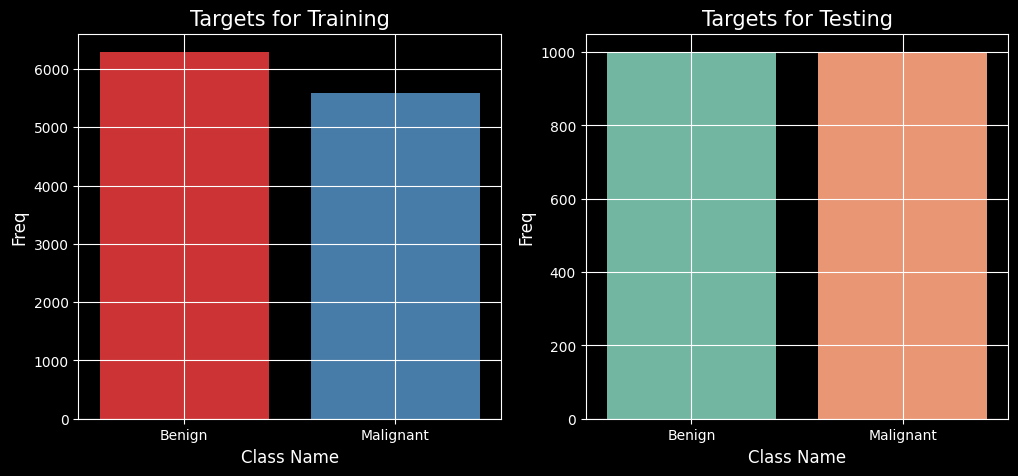

In [5]:
plt.style.use("dark_background")
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.countplot(x="Target",data=train_df,palette="Set1")
plt.title("Targets for Training",fontsize=15)
plt.xlabel("Class Name",fontsize=12)
plt.ylabel("Freq",fontsize=12)
plt.grid(True)
plt.subplot(1,2,2)
sns.countplot(x="Target",data=test_df,palette="Set2")
plt.title("Targets for Testing",fontsize=15)
plt.xlabel("Class Name",fontsize=12)
plt.ylabel("Freq",fontsize=12)
plt.grid(True)
plt.show()

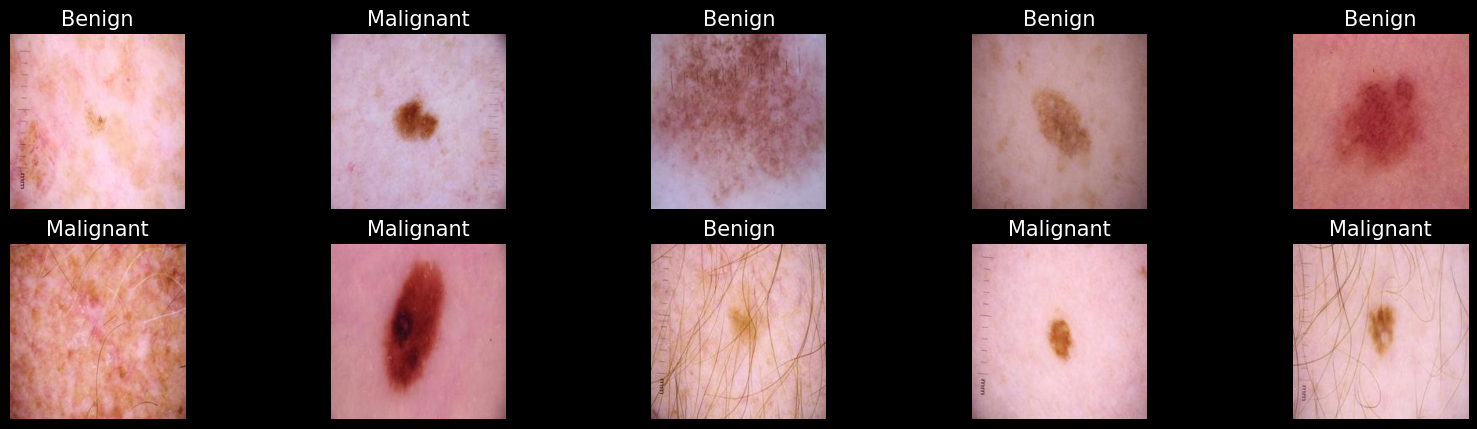

In [6]:
plt.figure(figsize=(20,5))
for index,image_index in enumerate(np.random.randint(0,len(train_df),10)):
    plt.subplot(2,5,index+1)
    image = cv2.imread(train_df["Image Path"][index])
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    image = cv2.resize(image,(224,224))
    plt.imshow(image)
    plt.axis('off')
    plt.title(train_df.Target[image_index],fontsize=15)

**Preprocessing**

In [7]:
train_df,val_df = train_test_split(train_df,test_size=.2,random_state=44,shuffle=True)
print(f"Train Size: {train_df.shape} , Test Size: {test_df.shape} , Validation Size: {val_df.shape} ")

Train Size: (9503, 2) , Test Size: (2000, 2) , Validation Size: (2376, 2) 


In [8]:
image_size = (224,224)
batch_size = 32
train_datagen = ImageDataGenerator(
    rescale= 1./255,
    rotation_range=30,
  #  width_shift_range=0.2,
    #height_shift_range=0.2,
    #shear_range=0.2,
   # zoom_range=0.2,
   horizontal_flip=True
)
test_datagen = ImageDataGenerator(
    rescale= 1./255
)
train_generator = train_datagen.flow_from_dataframe(
    dataframe= train_df,
    x_col= "Image Path",
    y_col= "Target",
    target_size= image_size,
    batch_size= batch_size,
    class_mode= "binary",
    shuffle= True
)
test_generator = test_datagen.flow_from_dataframe(
    dataframe= test_df,
    x_col= "Image Path",
    y_col= "Target",
    target_size= image_size,
    batch_size= batch_size,
    class_mode= "binary",
    shuffle= False
)
val_generator = test_datagen.flow_from_dataframe(
    dataframe= val_df,
    x_col= "Image Path",
    y_col= "Target",
    target_size= image_size,
    batch_size= batch_size,
    class_mode= "binary",
    shuffle= False
)

Found 9503 validated image filenames belonging to 2 classes.
Found 2000 validated image filenames belonging to 2 classes.
Found 2376 validated image filenames belonging to 2 classes.


**CNN Model**

In [9]:
model = Sequential()
model.add(Conv2D(32,(3,3),activation="relu",input_shape=(image_size[0],image_size[1],3)))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64,(3,3),activation="relu"))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(128,(3,3),activation="relu"))
model.add(MaxPooling2D(2,2))
model.add(Flatten())
model.add(Dense(512,activation="relu"))
model.add(Dropout(.5))
model.add(Dense(1,activation="sigmoid"))
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1765482806.493747      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,396,609 (169.36 MB)

 Trainable params: 44,396,609 (169.36 MB)

 Non-trainable params: 0 (0.00 B)

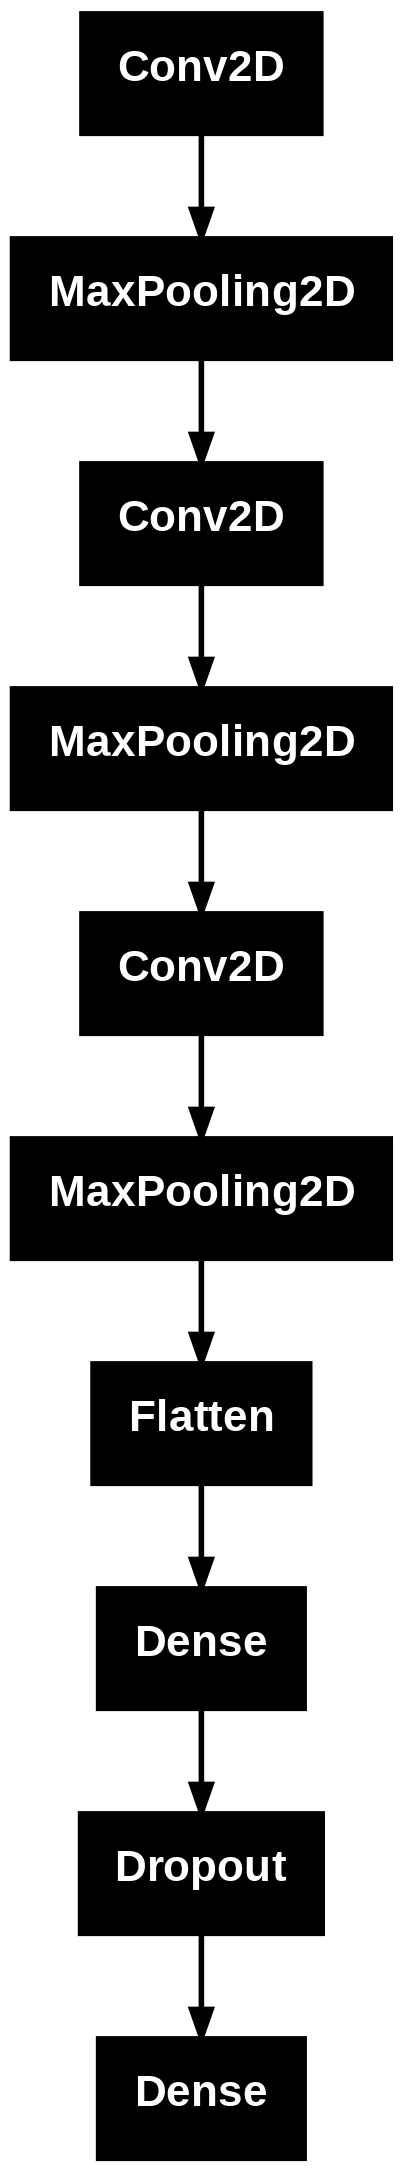

In [10]:
plot_model(model=model)

In [11]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])
early_stopping = EarlyStopping(
    patience=5,restore_best_weights=True,verbose=1
)
save_point = ModelCheckpoint(
    "Cancer.keras",save_best_only=True,verbose=1
)
lr = ReduceLROnPlateau(
    factor=.3,patience=5,min_lr=1e-7,verbose=1
)
history = model.fit(
    train_generator,
   # steps_per_epoch=train_generator.samples // batch_size,
    epochs=30,
    validation_data=val_generator,
   # validation_steps=val_generator.samples // batch_size,
    callbacks=[early_stopping, save_point, lr]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1765482811.764497      75 service.cc:148] XLA service 0x7eca90004e80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765482811.765483      75 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1765482812.186782      75 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/297 ━━━━━━━━━━━━━━━━━━━━ 35:45 7s/step - accuracy: 0.5000 - loss: 0.6788

I0000 00:00:1765482816.471711      75 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.6568 - loss: 0.8637
Epoch 1: val_loss improved from inf to 0.38173, saving model to Cancer.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 160s 516ms/step - accuracy: 0.6570 - loss: 0.8627 - val_accuracy: 0.8346 - val_loss: 0.3817 - learning_rate: 0.0010
Epoch 2/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.8170 - loss: 0.4145
Epoch 2: val_loss improved from 0.38173 to 0.35405, saving model to Cancer.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 119s 400ms/step - accuracy: 0.8170 - loss: 0.4145 - val_accuracy: 0.8481 - val_loss: 0.3540 - learning_rate: 0.0010
Epoch 3/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.8252 - loss: 0.3935
Epoch 3: val_loss improved from 0.35405 to 0.33803, saving model to Cancer.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 119s 401ms/step - accuracy: 0.8252 - loss: 0.3934 - val_accuracy: 0.8611 - val_loss: 0.3380 - learning_rate: 0.0010
Epoch 4/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.8388 

In [12]:
hist = pd.DataFrame(history.history)
hist

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.721035,0.588812,0.834596,0.381735,0.001
1,0.828160,0.399193,0.848064,0.354049,0.001
2,0.831843,0.383715,0.861111,0.338031,0.001
3,0.838262,0.387805,0.846801,0.338119,0.001
4,0.848785,0.363306,0.859848,0.318168,0.001
5,0.848574,0.359958,0.852273,0.333599,0.001
6,0.847838,0.348821,0.847222,0.336496,0.001
7,0.850468,0.352318,0.845539,0.352884,0.001
8,0.851731,0.346719,0.857323,0.340449,0.001
9,0.856572,0.339610,0.858165,0.315538,0.001


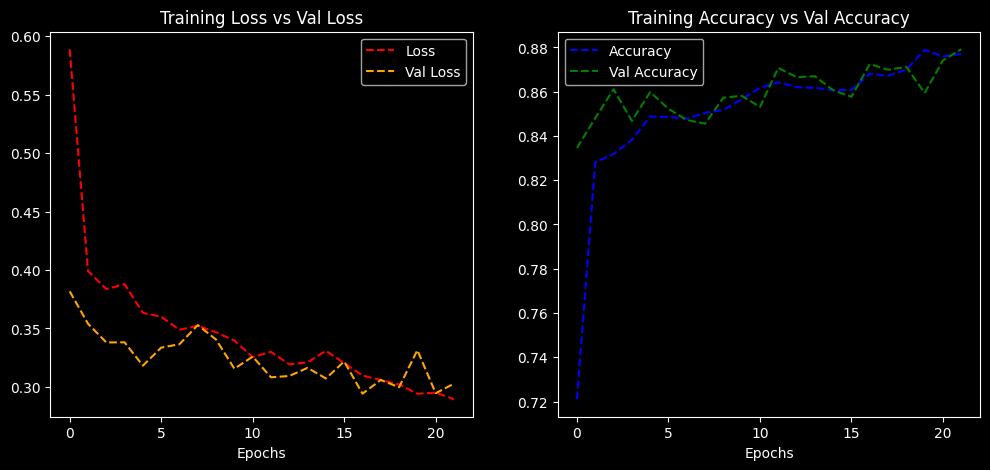

In [13]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(hist["loss"],'--',color="red")
plt.plot(hist["val_loss"],'--',color="orange")
plt.legend(["Loss","Val Loss"])
plt.title("Training Loss vs Val Loss",fontsize=12)
plt.xlabel("Epochs",fontsize=10)
plt.subplot(1,2,2)
plt.plot(hist["accuracy"],'--',color="blue")
plt.plot(hist["val_accuracy"],'--',color="green")
plt.legend(["Accuracy","Val Accuracy"])
plt.title("Training Accuracy vs Val Accuracy",fontsize=12)
plt.xlabel("Epochs",fontsize=10)
plt.show()

**Evaluation**

In [14]:
model = load_model("Cancer.keras")

In [15]:
loss,acc = model.evaluate(test_generator)
print(f"Test Loss: {loss} , Test Accuracy: {acc}")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 172ms/step - accuracy: 0.9105 - loss: 0.2453
Test Loss: 0.26460644602775574 , Test Accuracy: 0.9114999771118164


In [16]:
test_pred = model.predict(test_generator)
y_pred = (test_pred > .5).astype("int32")
y_test = test_generator.classes[:len(y_pred)]

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step


array([[909,  91],
       [ 86, 914]])

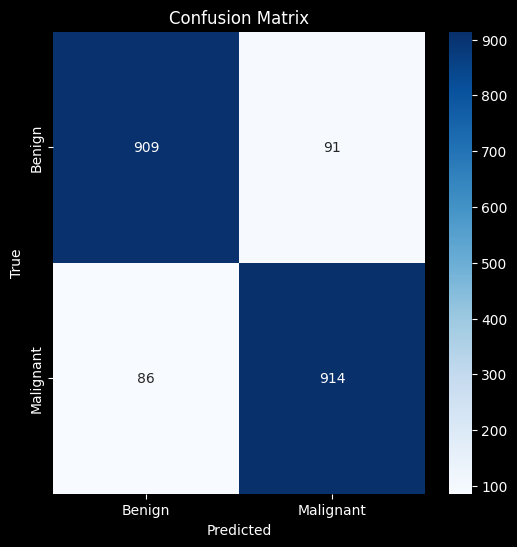

In [17]:
cm = confusion_matrix(y_test, y_pred)
# Plot Confusion Matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_generator.class_indices.keys(), yticklabels=train_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show
cm

In [18]:
print("Classification Report:\n",classification_report(y_test,y_pred,target_names=train_generator.class_indices.keys()))

Classification Report:
               precision    recall  f1-score   support

      Benign       0.91      0.91      0.91      1000
   Malignant       0.91      0.91      0.91      1000

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000



**DenseNet201**

In [19]:
base_model = DenseNet201(input_shape=(image_size[0],image_size[1],3),include_top=False,weights='imagenet')
base_model.trainable = False
#base_model.summary()

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [20]:
model = Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dense(512,activation="relu"))
model.add(Dropout(.5))
model.add(Dense(1,activation="sigmoid"))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet201 (Functional)        │ (None, 7, 7, 1920)     │    18,321,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 94080)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    48,169,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,491,969 (253.65 MB)

 Trainable params: 48,169,985 (183.75 MB)

 Non-trainable params: 18,321,984 (69.89 MB)

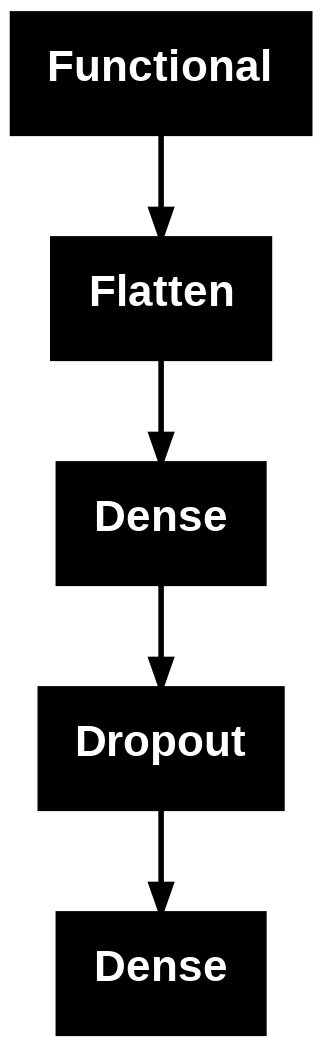

In [21]:
plot_model(model=model)

In [22]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])
early_stopping = EarlyStopping(
    patience=5,restore_best_weights=True,verbose=1
)
save_point = ModelCheckpoint(
    "Cancer_Transfer.keras",save_best_only=True,verbose=1
)
lr = ReduceLROnPlateau(
    factor=.3,patience=5,min_lr=1e-7,verbose=1
)
history = model.fit(
    train_generator,
   # steps_per_epoch=train_generator.samples // batch_size,
    epochs=30,
    validation_data=val_generator,
   # validation_steps=val_generator.samples // batch_size,
    callbacks=[early_stopping, save_point, lr]
)

Epoch 1/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.7734 - loss: 2.4657
Epoch 1: val_loss improved from inf to 0.31749, saving model to Cancer_Transfer.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 246s 662ms/step - accuracy: 0.7736 - loss: 2.4605 - val_accuracy: 0.8607 - val_loss: 0.3175 - learning_rate: 0.0010
Epoch 2/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.8554 - loss: 0.3387
Epoch 2: val_loss improved from 0.31749 to 0.29063, saving model to Cancer_Transfer.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 127s 427ms/step - accuracy: 0.8554 - loss: 0.3387 - val_accuracy: 0.8712 - val_loss: 0.2906 - learning_rate: 0.0010
Epoch 3/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.8714 - loss: 0.2987
Epoch 3: val_loss did not improve from 0.29063
297/297 ━━━━━━━━━━━━━━━━━━━━ 122s 411ms/step - accuracy: 0.8714 - loss: 0.2987 - val_accuracy: 0.8607 - val_loss: 0.2930 - learning_rate: 0.0010
Epoch 4/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.8751 - los

In [23]:
hist = pd.DataFrame(history.history)
hist

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.815322,0.908665,0.860690,0.317492,0.001
1,0.853625,0.332881,0.871212,0.290628,0.001
2,0.869831,0.298595,0.860690,0.292961,0.001
3,0.872251,0.300523,0.872896,0.284530,0.001
4,0.882248,0.278666,0.880892,0.270761,0.001
5,0.885194,0.275766,0.880892,0.276427,0.001
6,0.881511,0.273174,0.881734,0.283203,0.001
7,0.881195,0.275822,0.886364,0.268854,0.001
8,0.888351,0.262738,0.886784,0.257401,0.001
9,0.889403,0.262724,0.885943,0.264498,0.001


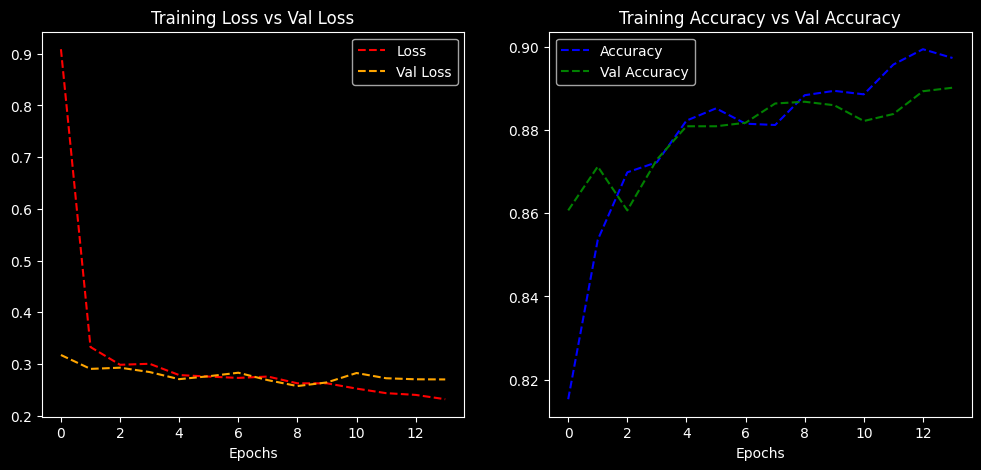

In [24]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(hist["loss"],'--',color="red")
plt.plot(hist["val_loss"],'--',color="orange")
plt.legend(["Loss","Val Loss"])
plt.title("Training Loss vs Val Loss",fontsize=12)
plt.xlabel("Epochs",fontsize=10)
plt.subplot(1,2,2)
plt.plot(hist["accuracy"],'--',color="blue")
plt.plot(hist["val_accuracy"],'--',color="green")
plt.legend(["Accuracy","Val Accuracy"])
plt.title("Training Accuracy vs Val Accuracy",fontsize=12)
plt.xlabel("Epochs",fontsize=10)
plt.show()

**Evaluation**

In [25]:
model = load_model("Cancer_Transfer.keras")

In [26]:
loss,acc = model.evaluate(test_generator)
print(f"Test Loss: {loss} , Test Accuracy: {acc}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 47s 386ms/step - accuracy: 0.9216 - loss: 0.1906
Test Loss: 0.23642510175704956 , Test Accuracy: 0.8999999761581421


In [27]:
test_pred = model.predict(test_generator)
y_pred = (test_pred > .5).astype("int32")
y_test = test_generator.classes[:len(y_pred)]

63/63 ━━━━━━━━━━━━━━━━━━━━ 46s 418ms/step


array([[930,  70],
       [130, 870]])

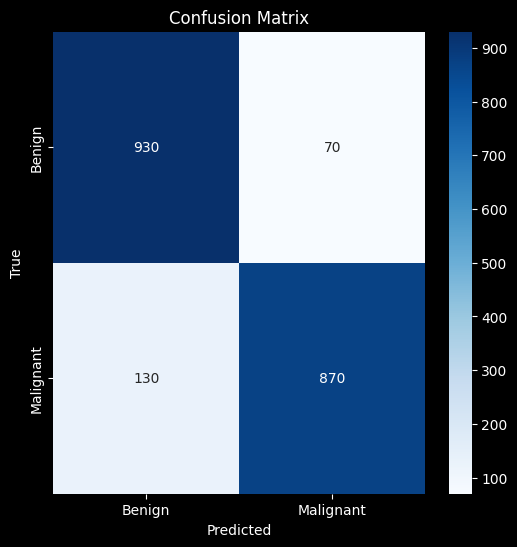

In [28]:
cm = confusion_matrix(y_test, y_pred)
# Plot Confusion Matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_generator.class_indices.keys(), yticklabels=train_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show
cm

In [29]:
print("Classification Report:\n",classification_report(y_test,y_pred,target_names=train_generator.class_indices.keys()))

Classification Report:
               precision    recall  f1-score   support

      Benign       0.88      0.93      0.90      1000
   Malignant       0.93      0.87      0.90      1000

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000

